# Time to Payback Analysis — Interactive Notebook

This notebook reproduces the payback analysis from `Pricescraper/6_analysis/time_to_payback_analysis.py` and displays all figures inline. It also writes the same outputs to `reports/figures/time_to_payback_analysis/` for record keeping.


In [1]:
# Imports and module loader
import sys
from pathlib import Path
from IPython.display import display, Image, Markdown

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pretty plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load analysis module by path (no package needed)
import importlib.util

# Notebook is in the same folder as the module
module_path = Path('time_to_payback_analysis.py')
spec = importlib.util.spec_from_file_location('time_to_payback_analysis', str(module_path))
ttpa = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ttpa)

# Output directory used by the script
figures_dir = Path('reports/figures/time_to_payback_analysis')
figures_dir.mkdir(parents=True, exist_ok=True)

figures_dir


WindowsPath('reports/figures/time_to_payback_analysis')

In [2]:
# Display analysis parameters
print("PAYBACK ANALYSIS PARAMETERS")
print("="*80)
print(f"Gas Boiler Costs: {ttpa.GAS_BOILER_COSTS}")
print(f"Gas Price: {ttpa.GAS_PRICE} EUR/kWh")
print(f"Electricity Price: {ttpa.ELECTRICITY_PRICE} EUR/kWh")
print(f"Gas Boiler Efficiency: {ttpa.GAS_BOILER_EFFICIENCY}")
print(f"\nHeating Demand Scenarios: {ttpa.HEATING_DEMAND_SCENARIOS}")
print(f"Grant: 35% of total investment, max 4500 EUR")
print(f"Dataset price represents 60% of total investment (40% installation cost)")
print("="*80)


PAYBACK ANALYSIS PARAMETERS
Gas Boiler Costs: {'low': 2500, 'medium': 3000, 'high': 3500}
Gas Price: 0.11 EUR/kWh
Electricity Price: 0.29 EUR/kWh
Gas Boiler Efficiency: 0.85

Heating Demand Scenarios: {'1_bedroom': 8000, '2-3_bedroom': 12000, '4+_bedroom': 17000}
Grant: 35% of total investment, max 4500 EUR
Dataset price represents 60% of total investment (40% installation cost)


In [3]:
# Ensure working directory is correct for data loading
import os
from pathlib import Path

# Ensure working directory is the project root so relative data paths work
needed = Path('data/processed/filtered_hplib_w_prices_and_decoding.csv')
if not needed.exists():
    # Walk up to 6 levels to find the repo root containing 'data/processed/...'
    cur = Path.cwd()
    for _ in range(6):
        candidate = cur / needed
        if candidate.exists():
            os.chdir(cur)
            break
        cur = cur.parent

# Perform payback analysis
result_df, summary = ttpa.payback_analysis()

# Display summary table
display(Markdown("### Average Payback Times by Scenario and Configuration"))
display(summary)


Average payback times (years) by scenario and configuration:
Configuration  monoblock - hydraulic module  monoblock - none  \
Scenario                                                        
1_bedroom                             16.14              6.44   
2-3_bedroom                           10.76              4.30   
4+_bedroom                             7.60              3.03   

Configuration  monoblock - warm-water tank  split - hydraulic module  \
Scenario                                                               
1_bedroom                            22.17                      8.38   
2-3_bedroom                          14.78                      5.59   
4+_bedroom                           10.43                      3.94   

Configuration  split - warm-water tank  
Scenario                                
1_bedroom                        12.51  
2-3_bedroom                       8.34  
4+_bedroom                        5.89  

EXAMPLE CALCULATIONS FOR EACH CONFIGURATION AN

### Average Payback Times by Scenario and Configuration

Configuration,monoblock - hydraulic module,monoblock - none,monoblock - warm-water tank,split - hydraulic module,split - warm-water tank
Scenario,,,,,
1_bedroom,16.144488,6.444336,22.172947,8.379997,12.514902
2-3_bedroom,10.762992,4.296224,14.781965,5.586664,8.343268
4+_bedroom,7.597406,3.032629,10.434328,3.943528,5.889366


Payback distribution plot saved to: reports\figures\time_to_payback_analysis\payback_distribution_by_configuration.png


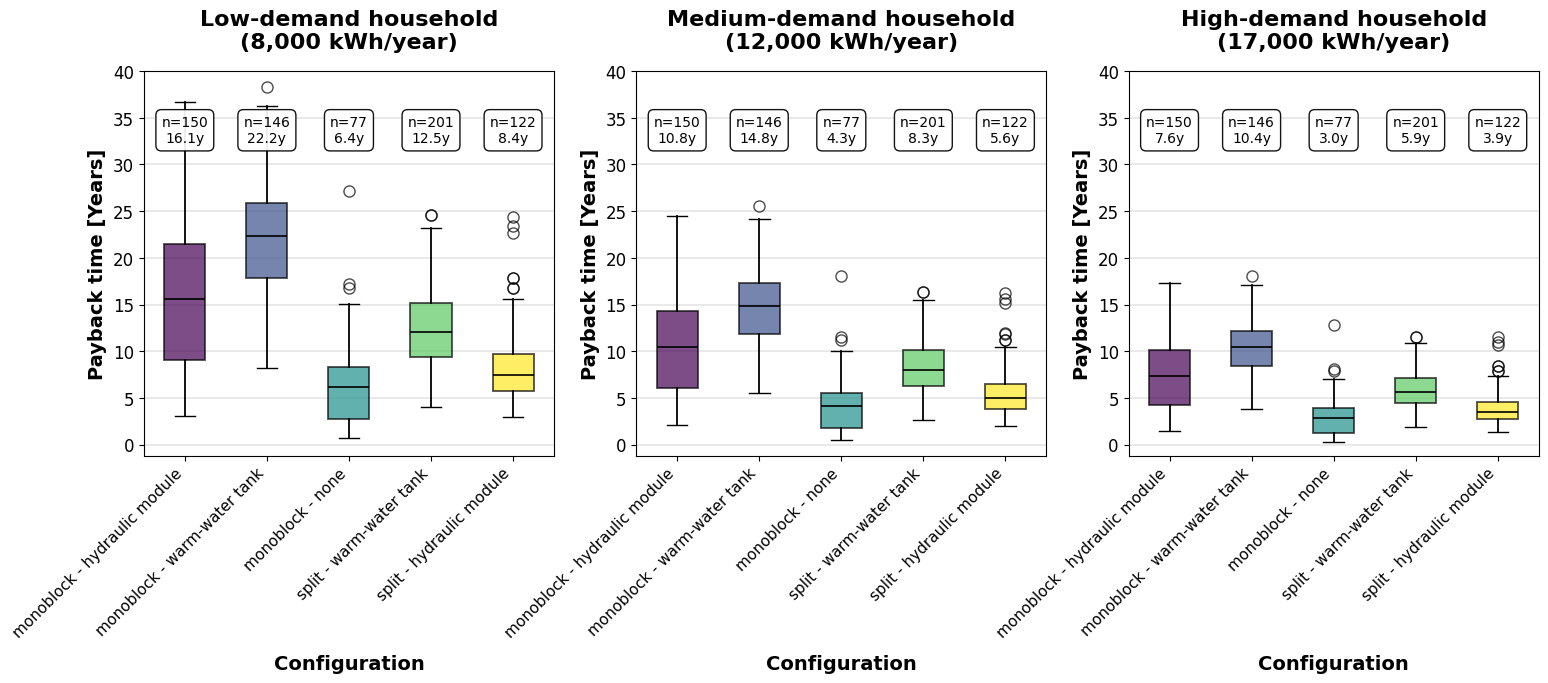

In [32]:
import matplotlib.colors as mcolors

# Set white background and no predefined color palette (we use viridis)
plt.style.use('default')

# Prepare color mapping using the viridis colormap
configs = result_df['Configuration'].unique()
monoblock_configs = [c for c in configs if 'monoblock' in c.lower()]
split_configs = [c for c in configs if 'split' in c.lower()]
sorted_configs = monoblock_configs + split_configs

n_configs = len(sorted_configs)
viridis = plt.get_cmap('viridis')
color_list = [viridis(i / max(n_configs-1, 1)) for i in range(n_configs)]
config_color_map = dict(zip(sorted_configs, color_list))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')
# fig.suptitle('Payback Time Distribution by Configuration and Heating Scenario', 
#              fontsize=24, fontweight='bold', y=0.98)

scenarios = ['1_bedroom', '2-3_bedroom', '4+_bedroom']
scenario_labels = [
    'Low-demand household\n(8,000 kWh/year)',
    'Medium-demand household\n(12,000 kWh/year)',
    'High-demand household\n(17,000 kWh/year)'
]

# -- Calculate unified ylims based on first subplot's data --
first_scenario_data = result_df[result_df['Scenario'] == scenarios[0]].copy()
first_payback = first_scenario_data['Payback_Years'].dropna()
if len(first_payback) > 0:
    payback_range = first_payback.max() - first_payback.min()
    y_min = min(0, float(first_payback.min()) - 0.05 * payback_range)
    y_max = float(first_payback.max()) + max(1.8, 0.04 * float(first_payback.max()))
else:
    y_min, y_max = 0, 10  # Fallback

# -- Compute annotation y-location for all subplots based on first subplot's data
# y_anno = y_max - 1.1 * max(1.5, 0.05 * (y_max if y_max > 0 else 10))
y_anno = 0.8 * y_max 

for i, (scenario, label) in enumerate(zip(scenarios, scenario_labels)):
    scenario_data = result_df[result_df['Scenario'] == scenario].copy()
    if len(scenario_data) > 0:
        valid_configs = [config for config in sorted_configs if config in scenario_data['Configuration'].unique()]
        valid_colors = [config_color_map.get(config, (0.5, 0.5, 0.5, 1)) for config in valid_configs]

        if valid_configs:
            box_data = [scenario_data[scenario_data['Configuration'] == config]['Payback_Years'].dropna() 
                        for config in valid_configs]

            # Make the boxplot with reduced black line widths for boxes, whiskers, and medians
            boxprops = dict(linestyle='-', linewidth=1.3, color='black')
            whiskerprops = dict(linestyle='-', linewidth=1.3, color='black')
            capprops = dict(linestyle='-', linewidth=1, color='black')
            medianprops = dict(linestyle='-', linewidth=1.2, color='black')
            flierprops = dict(marker='o', color='black', alpha=0.7, markersize=8)

            bp = axes[i].boxplot(
                box_data, 
                labels=valid_configs, 
                patch_artist=True,
                boxprops=boxprops,
                whiskerprops=whiskerprops,
                capprops=capprops,
                medianprops=medianprops,
                flierprops=flierprops
            )

            for patch, color in zip(bp['boxes'], valid_colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)

            # Place annotation text boxes at the unified y_anno for all subplots
            for j, config in enumerate(valid_configs):
                config_data = scenario_data[scenario_data['Configuration'] == config]['Payback_Years'].dropna()
                if len(config_data) > 0:
                    mean_val = config_data.mean()
                    count = len(config_data)
                    axes[i].text(
                        j+1, y_anno,
                        f"n={count}\n{mean_val:.1f}y",
                        ha='center', va='bottom',
                        fontsize=10, 
                        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.92)
                    )
        axes[i].set_title(label, fontsize=16, fontweight='bold', pad=16)
        axes[i].set_ylabel('Payback time [Years]', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Configuration', fontsize=14, fontweight='bold', labelpad=10)
        axes[i].tick_params(axis='x', labelsize=12, rotation=45)
        axes[i].tick_params(axis='y', labelsize=12)
        if valid_configs:
            axes[i].set_xticklabels(valid_configs, rotation=45, ha='right', fontsize=11)
        axes[i].grid(True, alpha=0.3, axis='y', linewidth=1.3)

        # Set unified y-lims for all plots
        axes[i].set_ylim(y_min, y_max)
    else:
        axes[i].text(
            0.5, 0.5, 'No data available',
            ha='center', va='center',
            transform=axes[i].transAxes, fontsize=12
        )
        axes[i].set_title(label, fontsize=16, fontweight='bold')
        axes[i].set_ylim(y_min, y_max)

# plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save figure
figures_dir.mkdir(parents=True, exist_ok=True)
# plt.savefig(figures_dir / 'payback_distribution_by_configuration.png', dpi=300, bbox_inches='tight')

print(f"Payback distribution plot saved to: {figures_dir / 'payback_distribution_by_configuration.png'}")


In [8]:
# Create payback plot and display it inline
create_payback_plot(result_df, figures_dir)

# Display the plot
plot_path = figures_dir / 'payback_distribution_by_configuration.png'
if plot_path.exists():
    display(Markdown("### Payback Time Distribution by Configuration and Heating Scenario"))
    display(Image(filename=str(plot_path)))
else:
    print(f"Warning: {plot_path} not found")


NameError: name 'mcolors' is not defined

In [5]:
# Additional statistics and summary
print("\n" + "="*80)
print("ADDITIONAL PAYBACK STATISTICS")
print("="*80)

# Overall statistics by scenario
for scenario in ['1_bedroom', '2-3_bedroom', '4+_bedroom']:
    scenario_data = result_df[result_df['Scenario'] == scenario]['Payback_Years'].dropna()
    if len(scenario_data) > 0:
        scenario_name = scenario.replace('_', ' ').title()
        print(f"\n{scenario_name}:")
        print(f"  Mean payback: {scenario_data.mean():.2f} years")
        print(f"  Median payback: {scenario_data.median():.2f} years")
        print(f"  Min payback: {scenario_data.min():.2f} years")
        print(f"  Max payback: {scenario_data.max():.2f} years")
        print(f"  Valid calculations: {len(scenario_data)} out of {len(result_df[result_df['Scenario'] == scenario])}")

# Statistics by configuration (across all scenarios)
print(f"\n{'='*80}")
print("PAYBACK STATISTICS BY CONFIGURATION (All Scenarios Combined)")
print("="*80)
for config in result_df['Configuration'].unique():
    config_data = result_df[result_df['Configuration'] == config]['Payback_Years'].dropna()
    if len(config_data) > 0:
        print(f"\n{config}:")
        print(f"  Mean payback: {config_data.mean():.2f} years")
        print(f"  Median payback: {config_data.median():.2f} years")
        print(f"  Min payback: {config_data.min():.2f} years")
        print(f"  Max payback: {config_data.max():.2f} years")
        print(f"  Valid calculations: {len(config_data)} out of {len(result_df[result_df['Configuration'] == config])}")

print("\n" + "="*80)



ADDITIONAL PAYBACK STATISTICS

1 Bedroom:
  Mean payback: 13.93 years
  Median payback: 12.65 years
  Min payback: 0.71 years
  Max payback: 38.26 years
  Valid calculations: 696 out of 696

2-3 Bedroom:
  Mean payback: 9.28 years
  Median payback: 8.43 years
  Min payback: 0.47 years
  Max payback: 25.51 years
  Valid calculations: 696 out of 696

4+ Bedroom:
  Mean payback: 6.55 years
  Median payback: 5.95 years
  Min payback: 0.33 years
  Max payback: 18.00 years
  Valid calculations: 696 out of 696

PAYBACK STATISTICS BY CONFIGURATION (All Scenarios Combined)

monoblock - hydraulic module:
  Mean payback: 11.50 years
  Median payback: 9.88 years
  Min payback: 1.47 years
  Max payback: 36.74 years
  Valid calculations: 450 out of 450

monoblock - warm-water tank:
  Mean payback: 15.80 years
  Median payback: 14.87 years
  Min payback: 3.86 years
  Max payback: 38.26 years
  Valid calculations: 438 out of 438

split - warm-water tank:
  Mean payback: 8.92 years
  Median payback: 8

In [6]:
# Display sample of results dataframe
display(Markdown("### Sample Results Data"))
display(result_df.head(10))
print(f"\nTotal rows: {len(result_df)}")
print(f"Columns: {', '.join(result_df.columns)}")


### Sample Results Data

,Model,Manufacturer,Configuration,Scenario,Rated_Power_kW,SCOP,HP_Total_Investment,HP_Total_Investment_After_Grant,Grant_Amount,Gas_Boiler_Cost,Upfront_Diff,Annual_Savings,Payback_Years
0,Bosch CS5800i/6800iAW 4/5/7 OR,Bosch Thermotechnik GmbH,monoblock - hydraulic module,1_bedroom,6.6,4.58,16555.000000,12055.000000,4500.0,3000,9055.000000,528.743899,17.125493
1,Bosch CS5800i/6800iAW 4/5/7 OR,Bosch Thermotechnik GmbH,monoblock - warm-water tank,1_bedroom,4.4,4.55,18331.666667,13831.666667,4500.0,2500,11331.666667,525.404008,21.567530
2,Bosch CS5800i/6800iAW 4/5/7 OR,Bosch Thermotechnik GmbH,monoblock - hydraulic module,1_bedroom,6.2,4.55,18331.666667,13831.666667,4500.0,3000,10831.666667,525.404008,20.615881
3,Bosch CS5800i/6800iAW 4/5/7 OR,Bosch Thermotechnik GmbH,monoblock - hydraulic module,1_bedroom,4.4,4.55,18331.666667,13831.666667,4500.0,2500,11331.666667,525.404008,21.567530
4,Bosch CS5800i/6800iAW 4/5/7 OR,Bosch Thermotechnik GmbH,monoblock - hydraulic module,1_bedroom,6.6,4.56,19165.000000,14665.000000,4500.0,3000,11665.000000,526.522188,22.154812
5,Bosch CS5800i/6800iAW 4/5/7 OR,Bosch Thermotechnik GmbH,monoblock - hydraulic module,1_bedroom,4.4,4.55,17665.000000,13165.000000,4500.0,2500,10665.000000,525.404008,20.298665
6,Bosch CS5800i/6800iAW 10/12 OR,Bosch Thermotechnik GmbH,monoblock - warm-water tank,1_bedroom,10.0,4.73,23331.666667,18831.666667,4500.0,3500,15331.666667,544.807860,28.141420
7,Bosch CS5800i/6800iAW 4/5/7 OR,Bosch Thermotechnik GmbH,monoblock - warm-water tank,1_bedroom,6.6,4.56,19998.333333,15498.333333,4500.0,3000,12498.333333,526.522188,23.737525
8,Bosch CS5800i/6800iAW 10/12 OR,Bosch Thermotechnik GmbH,monoblock - hydraulic module,1_bedroom,12.2,4.64,24998.333333,20498.333333,4500.0,3500,16998.333333,535.294118,31.755128
9,Bosch CS5800i/6800iAW 4/5/7 OR,Bosch Thermotechnik GmbH,monoblock - hydraulic module,1_bedroom,4.4,4.58,16665.000000,12165.000000,4500.0,2500,9665.000000,528.743899,18.279171



Total rows: 2088
Columns: Model, Manufacturer, Configuration, Scenario, Rated_Power_kW, SCOP, HP_Total_Investment, HP_Total_Investment_After_Grant, Grant_Amount, Gas_Boiler_Cost, Upfront_Diff, Annual_Savings, Payback_Years
